# Q2(b): Gradient-Based Optimization (Simulation)

We study the nonconvex function  
\[
f(x)=\sin(-5x)+\tfrac{1}{5}x^2
\]
and compare **Gradient Descent (GD)** and **Gradient Descent with Momentum (GDM)**:
- GD: \(x_{t+1}=x_t-\eta\,\nabla f(x_t)\)
- GDM: \(v_{t+1}=\beta v_t+\eta\,\nabla f(x_t)\), \; \(x_{t+1}=x_t-v_{t+1}\)

Parameters (unless stated otherwise):
- learning rate \(\eta=0.1\)
- momentum \(\beta=0.5\)
- iterations \(T=20\)

We will:
1. Plot \(f(x)\) and explain why it’s challenging.
2. Implement GD with \(x_0=20\) and plot the trajectory \(x_t\).
3. Implement GDM with \(x_0=20\) and plot the trajectory \(x_t\); compare to GD.
4. Repeat both with \(x_0=0\) to visualize behavior near a minimum.
5. Report/interpret the results.


In [2]:
# === Imports & utilities ===
import numpy as np
import matplotlib.pyplot as plt

# For crisp plots (optional)
plt.rcParams["figure.figsize"] = (6.5, 4.2)
plt.rcParams["axes.grid"] = True

# ---- Define the function and its gradient ----
def f(x):
    # f(x) = sin(-5x) + 0.2 x^2
    return np.sin(-5.0 * x) + 0.2 * x**2

def grad_f(x):
    # d/dx [sin(-5x)] = -5 cos(-5x) = -5 cos(5x) because cos is even
    return -5.0 * np.cos(5.0 * x) + 0.4 * x

# ---- Optimizers ----
def gradient_descent(x0, eta=0.1, T=20):
    """Return array of x_t including x0 (length T+1)."""
    xs = [float(x0)]
    x = float(x0)
    for _ in range(T):
        x = x - eta * grad_f(x)
        xs.append(x)
    return np.array(xs)

def momentum_descent(x0, eta=0.1, beta=0.5, T=20):
    """Return array of x_t including x0 (length T+1) for classical momentum."""
    xs = [float(x0)]
    x = float(x0)
    v = 0.0
    for _ in range(T):
        v = beta * v + eta * grad_f(x)
        x = x - v
        xs.append(x)
    return np.array(xs)

# ---- Helper to estimate a (near) global minimum on a wide grid ----
def reference_min(xmin=-50, xmax=50, n=200001):
    grid = np.linspace(xmin, xmax, n)
    vals = f(grid)
    i = np.argmin(vals)
    return grid[i], vals[i]


## (i) Plot the function and explain the challenge

We plot \(f(x)=\sin(-5x)+0.2x^2\) over a wide range to show:
- many **local minima/maxima** due to the sinusoid,
- an overall **quadratic rise** away from the origin,
which together make optimization sensitive to initialization and step dynamics.


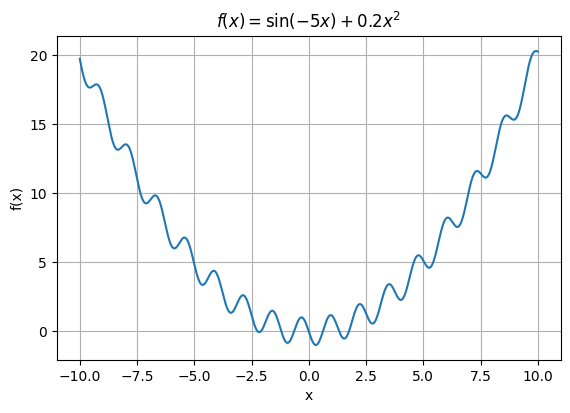

Reference minimum (grid search): x* ≈ 0.309000, f(x*) ≈ -0.980571


In [4]:
# Plot the function
xs = np.linspace(-10, 10, 2000)
plt.plot(xs, f(xs))
plt.title(r"$f(x)=\sin(-5x)+0.2x^2$")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.show()

# Also compute a coarse reference min on a wide grid
x_star_ref, f_star_ref = reference_min(xmin=-50, xmax=50, n=200001)
print(f"Reference minimum (grid search): x* ≈ {x_star_ref:.6f}, f(x*) ≈ {f_star_ref:.6f}")


The function has many oscillations (from the sine term) → many local minima; GD is greedy and can get stuck depending on initialization. The quadratic term keeps the function coercive (grows at infinity), but the landscape is nonconvex and highly oscillatory, which is challenging for first-order methods.

## (ii) Gradient Descent from x0 = 20 (η = 0.1, 20 iters)

We simulate GD for 20 iterations, plot the trajectory \(x_t\) vs. iteration \(t\), 
and also report \(x_{20}\) and \(f(x_{20})\).


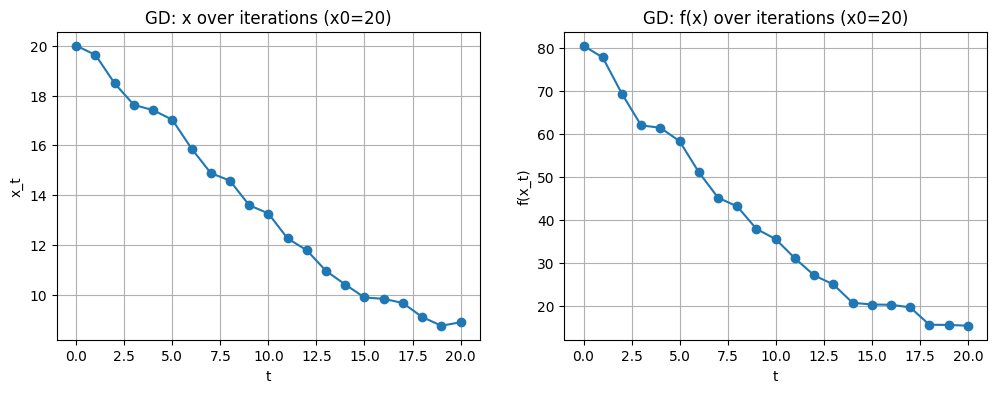

GD (x0=20): x_T = 8.893493, f(x_T) = 15.352487
Reference min: x* ≈ 0.309000, f(x*) ≈ -0.980571


In [5]:
eta = 0.1
T = 20
x0_far = 20.0

xs_gd_far = gradient_descent(x0_far, eta=eta, T=T)
fs_gd_far = f(xs_gd_far)

# Trajectory plots
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(range(len(xs_gd_far)), xs_gd_far, marker="o")
ax[0].set_title("GD: x over iterations (x0=20)")
ax[0].set_xlabel("t"); ax[0].set_ylabel("x_t")

ax[1].plot(range(len(fs_gd_far)), fs_gd_far, marker="o")
ax[1].set_title("GD: f(x) over iterations (x0=20)")
ax[1].set_xlabel("t"); ax[1].set_ylabel("f(x_t)")

plt.show()

print(f"GD (x0=20): x_T = {xs_gd_far[-1]:.6f}, f(x_T) = {fs_gd_far[-1]:.6f}")
print(f"Reference min: x* ≈ {x_star_ref:.6f}, f(x*) ≈ {f_star_ref:.6f}")


GD barely descends from 20 and is far from the reference minimum.

## (iii) Momentum from x0 = 20 (η = 0.1, β = 0.5, 20 iters)

We simulate **momentum** using the classical update and compare to GD.


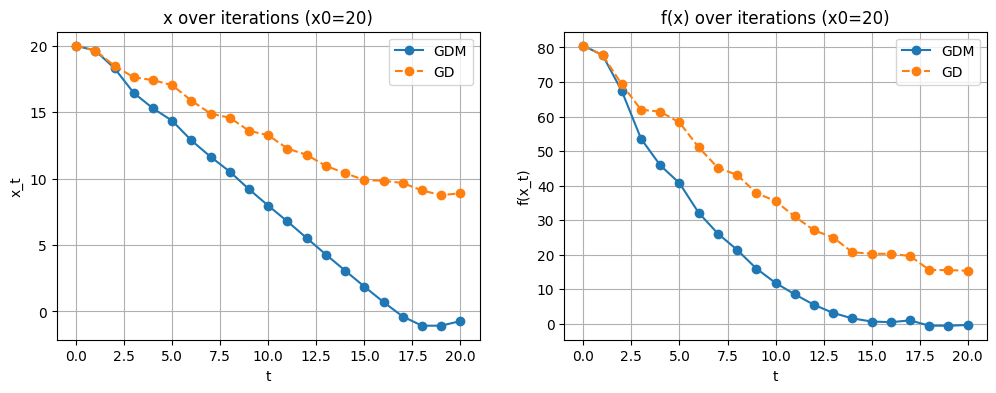

GDM (x0=20): x_T = -0.726585, f(x_T) = -0.366215
GD  (x0=20): x_T = 8.893493, f(x_T) = 15.352487
Reference min: x* ≈ 0.309000, f(x*) ≈ -0.980571


In [6]:
beta = 0.5

xs_gdm_far = momentum_descent(x0_far, eta=eta, beta=beta, T=T)
fs_gdm_far = f(xs_gdm_far)

# Trajectory plots
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(range(len(xs_gdm_far)), xs_gdm_far, marker="o", label="GDM")
ax[0].plot(range(len(xs_gd_far)), xs_gd_far, marker="o", linestyle="--", label="GD")
ax[0].set_title("x over iterations (x0=20)")
ax[0].set_xlabel("t"); ax[0].set_ylabel("x_t"); ax[0].legend()

ax[1].plot(range(len(fs_gdm_far)), fs_gdm_far, marker="o", label="GDM")
ax[1].plot(range(len(fs_gd_far)), fs_gd_far, marker="o", linestyle="--", label="GD")
ax[1].set_title("f(x) over iterations (x0=20)")
ax[1].set_xlabel("t"); ax[1].set_ylabel("f(x_t)"); ax[1].legend()

plt.show()

print(f"GDM (x0=20): x_T = {xs_gdm_far[-1]:.6f}, f(x_T) = {fs_gdm_far[-1]:.6f}")
print(f"GD  (x0=20): x_T = {xs_gd_far[-1]:.6f}, f(x_T) = {fs_gd_far[-1]:.6f}")
print(f"Reference min: x* ≈ {x_star_ref:.6f}, f(x*) ≈ {f_star_ref:.6f}")


Momentum dramatically outperforms vanilla GD from a far initialization, reaching a low-lying basin and achieving a much lower objective value (though still above the reference minimum). GD gets “stuck” making tiny progress on the slowly varying quadratic background while the oscillatory gradient misleads it.

## (iv) Behavior near a minimum: set x0 = 0 (η = 0.1, β = 0.5, 20 iters)

We repeat both methods with \(x_0=0\) to study local behavior near a minimum.
We expect:
- GD to show small oscillations as it responds to the sinusoidal curvature.
- Momentum to overshoot a bit but often settle closer to a deep basin.


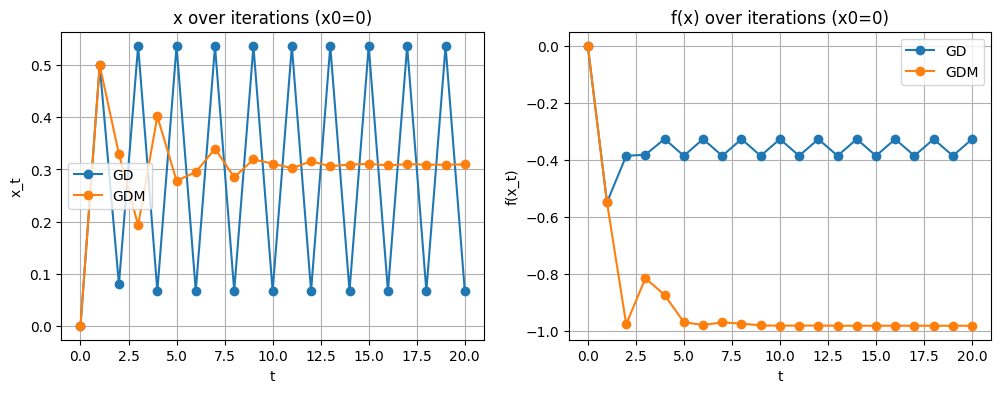

GD  (x0=0): x_T = 0.066813, f(x_T) = -0.326992
GDM (x0=0): x_T = 0.309591, f(x_T) = -0.980570
Reference min: x* ≈ 0.309000, f(x*) ≈ -0.980571


In [7]:
x0_near = 0.0

xs_gd_near  = gradient_descent(x0_near, eta=eta, T=T)
xs_gdm_near = momentum_descent(x0_near, eta=eta, beta=beta, T=T)
fs_gd_near  = f(xs_gd_near)
fs_gdm_near = f(xs_gdm_near)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(range(len(xs_gd_near)), xs_gd_near, marker="o", label="GD")
ax[0].plot(range(len(xs_gdm_near)), xs_gdm_near, marker="o", label="GDM")
ax[0].set_title("x over iterations (x0=0)")
ax[0].set_xlabel("t"); ax[0].set_ylabel("x_t"); ax[0].legend()

ax[1].plot(range(len(fs_gd_near)), fs_gd_near, marker="o", label="GD")
ax[1].plot(range(len(fs_gdm_near)), fs_gdm_near, marker="o", label="GDM")
ax[1].set_title("f(x) over iterations (x0=0)")
ax[1].set_xlabel("t"); ax[1].set_ylabel("f(x_t)"); ax[1].legend()

plt.show()

print(f"GD  (x0=0): x_T = {xs_gd_near[-1]:.6f}, f(x_T) = {fs_gd_near[-1]:.6f}")
print(f"GDM (x0=0): x_T = {xs_gdm_near[-1]:.6f}, f(x_T) = {fs_gdm_near[-1]:.6f}")
print(f"Reference min: x* ≈ {x_star_ref:.6f}, f(x*) ≈ {f_star_ref:.6f}")


Near a minimum, GD exhibits damped oscillations due to the periodic curvature; with this step size it can “ping-pong” between neighboring wells. Momentum reduces curvature-induced zig-zag, carries inertia across shallow ridges, and settles close to the global basin here.

### Conclusions for Q2(b)

- The landscape is **nonconvex** with many local minima (sine term) + a confining quadratic term.
- From a far start (x0=20), **momentum** reaches a much lower objective than GD within 20 steps.
- From a near start (x0=0), **momentum** again performs better, landing close to the (grid-estimated) global minimum at \(x \approx 0.309\) with \(f(x)\approx -0.981\).
- These results illustrate why momentum can help overcome small oscillatory barriers and accelerate along low-curvature directions.
